# ResNet50 Transfer Learning - Stanford Dogs

Purpose: demonstrate transfer learning with ResNet50 on the Stanford Dogs dataset.

**Training strategy:**
1. **Frozen phase** - only classifier head is trained with the backbone frozen
2. **Fine-tuning phase** - top layers are unfreezed and train end-to-end with a lower learning rate

The contents of this notebook:

- [ResNet50](#resnet50)
  - [1. Imports & Setup](#1-imports-setup)
  - [2. Load Raw Dataset](#2-load-raw-dataset)
  - [3. Preprocess Dataset](#3-preprocess-dataset)
  - [4. Phase 1: Train with Frozen Backbone](#4-phase-1-train-with-frozen-backbone)
  - [5. Phase 2: Fine-Tuning](#5-phase-2-fine-tuning)
  - [6. Compare Frozen vs Fine-Tuned](#6-compare-frozen-vs-fine-tuned)
  - [7. Evaluations](#7-evaluations)
  - [8. Summary](#8-summary)

## ResNet50

### 1. Imports & Setup

In [2]:
import sys
sys.path.insert(0, "..")

import os
import json
import yaml
import numpy as np
import tensorflow as tf
from tensorflow import keras

# Load configuration
cfg = yaml.safe_load(open("../config/default.yaml"))

# Set random seed for reproducibility
tf.random.set_seed(cfg["seed"])
np.random.seed(cfg["seed"])

print(f"TensorFlow version: {tf.__version__}")
print(f"Random seed: {cfg['seed']}")

TensorFlow version: 2.20.0
Random seed: 42


### 2. Load Raw Dataset

In [3]:
from src.data.dataset import load_stanford_dogs, get_num_classes

(train_ds, test_ds), ds_info, class_names = load_stanford_dogs(as_supervised=True)
num_classes = get_num_classes(ds_info)

print(f"Dataset: {ds_info.name}")
print(f"Train samples: {ds_info.splits['train'].num_examples}")
print(f"Test samples: {ds_info.splits['test'].num_examples}")
print(f"Number of classes: {num_classes}")
print(f"Sample classes: {class_names[:5]}")

Dataset: stanford_dogs
Train samples: 12000
Test samples: 8580
Number of classes: 120
Sample classes: ['chihuahua', 'japanese_spaniel', 'maltese_dog', 'pekinese', 'shih-tzu']


### 3. Preprocess Dataset

The preprocessing pipeline contains:
1. Resize images to 224×224
2. Augment training images (flip, rotate, zoom, translate, contrast)
3. Normalize using ResNet50's preprocessing function

In [4]:
from src.data.preprocessing import preprocess_dataset, inspect_dataset

train_prep, val_prep = preprocess_dataset(
    train_ds=train_ds,
    valid_ds=test_ds,
    model_names=["resnet50"],
    img_size=cfg["dataset"]["img_size"],
    batch_size=cfg["dataset"]["batch_size"],
)
inspect_dataset(train_prep, val_prep, class_names, model_names=["resnet50"])


Training batches  : 375
Validation batches: 269

Training split
----------------------------------------
[resnet50]
    shape : (32, 224, 224, 3)
    dtype : <dtype: 'float32'>
    range : [-123.68, 151.06]
[labels]
    shape : (32,)

Validation split
----------------------------------------
[resnet50]
    shape : (32, 224, 224, 3)
    dtype : <dtype: 'float32'>
    range : [-123.68, 151.06]
[labels]
    shape : (32,)

Classes          : 120
Sample names     : ['chihuahua', 'japanese_spaniel', 'maltese_dog', 'pekinese', 'shih-tzu']


### 4. Phase 1:  Train with Frozen Backbone

A ResNet50 model pretrained on ImageNet is used as the feature extractor.
The backbone is frozen and only the classifier head is trained initially.

In [9]:
# Build model
from src.models.resnet50 import build_resnet50, count_trainable_params
tf.keras.backend.clear_session()

model = build_resnet50(
    num_classes=num_classes,
    img_size=cfg["dataset"]["img_size"],
    frozen=True,
    dropout=cfg["models"]["resnet50"]["dropout"],
    global_pooling=cfg["models"]["resnet50"]["global_pooling"],
)

# Count parameters
# trainable, non_trainable = count_trainable_params(model)
# print(f"\nTrainable parameters: {trainable:,}")
# print(f"Non-trainable parameters: {non_trainable:,}")
# print(f"Total parameters: {trainable + non_trainable:,}")

model.summary()

Model: "ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_pool                     │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 120)            │       245,880 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,833,592 (90.92 MB)

 Trainable params: 245,880 (960.47 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [10]:
# compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=cfg["training"]["frozen"]["initial_lr"]),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        "accuracy",
        keras.metrics.SparseTopKCategoricalAccuracy(k=5, name="top_5_accuracy")
    ]
)

In [11]:
# set up callbacks
from src.training.callbacks import create_callbacks
os.makedirs(cfg["paths"]["checkpoints"], exist_ok=True)

callbacks_frozen = create_callbacks(
    checkpoint_path=os.path.join(cfg["paths"]["checkpoints"], "resnet50_frozen.keras"),
    monitor="val_accuracy",
    mode="max",
    early_stop_patience=cfg["training"]["frozen"]["early_stop_patience"],
    reduce_lr_patience=cfg["training"]["frozen"]["reduce_lr_patience"],
    reduce_lr_factor=cfg["training"]["frozen"]["reduce_lr_factor"],
)

In [7]:
# Train model
history_frozen = model.fit(
    train_prep,
    validation_data=val_prep,
    epochs=cfg["training"]["frozen"]["epochs"],
    callbacks=callbacks_frozen,
)

Epoch 1/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.1765 - loss: 4.1438 - top_5_accuracy: 0.3837
Epoch 1: val_accuracy improved from None to 0.66970, saving model to ../artefacts/checkpoints\resnet50_frozen.keras

Epoch 1: finished saving model to ../artefacts/checkpoints\resnet50_frozen.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 1720s 5s/step - accuracy: 0.2974 - loss: 3.1222 - top_5_accuracy: 0.5750 - val_accuracy: 0.6697 - val_loss: 1.1063 - val_top_5_accuracy: 0.9347 - learning_rate: 0.0010
Epoch 2/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5020 - loss: 1.8997 - top_5_accuracy: 0.8145
Epoch 2: val_accuracy improved from 0.66970 to 0.73193, saving model to ../artefacts/checkpoints\resnet50_frozen.keras

Epoch 2: finished saving model to ../artefacts/checkpoints\resnet50_frozen.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 1672s 4s/step - accuracy: 0.5178 - loss: 1.8471 - top_5_accuracy: 0.8251 - val_accuracy: 0.7319 - val_loss: 0.8924 - val_top_5_accuracy: 0.9559 - learning_

In [8]:
# evaluate model
from src.evaluation.metrics import evaluate_model
from src.evaluation.viz import plot_training_history

results_frozen = evaluate_model(model, val_prep, verbose=1)
print(f"\nLoss: {results_frozen['loss']:.4f}")
print("Frozen Model Evaluation")
print(f"Accuracy: {results_frozen['accuracy']:.4f}")
print(f"Top-5 Accuracy: {results_frozen['top_5_accuracy']:.4f}")

269/269 ━━━━━━━━━━━━━━━━━━━━ 629s 2s/step - accuracy: 0.7756 - loss: 0.8195 - top_5_accuracy: 0.9669

Loss: 0.8195
Frozen Model Evaluation
Accuracy: 0.7756
Top-5 Accuracy: 0.9669


Saved plot to ../artefacts/evaluations\resnet50_frozen_history.png


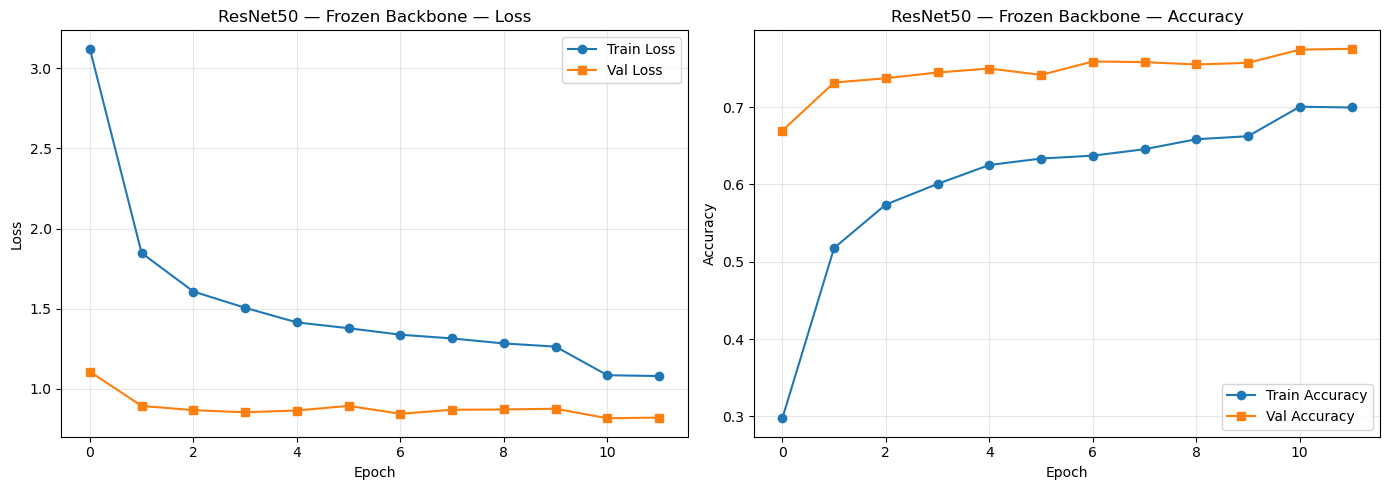

In [9]:
# plot training history
os.makedirs(cfg["paths"]["evaluations"], exist_ok=True)
plot_training_history(
    history_frozen.history,
    title="ResNet50 — Frozen Backbone",
    save_path=os.path.join(cfg["paths"]["evaluations"], "resnet50_frozen_history.png"),
)

In [10]:
# Save history as JSON
os.makedirs(cfg["paths"]["histories"], exist_ok=True)
with open(os.path.join(cfg["paths"]["histories"], "resnet50_frozen.json"), "w") as f:
    json.dump(history_frozen.history, f, indent=2)

print("Frozen training history saved.")

Frozen training history saved.


### 5. Phase 2: Fine-Tuning

For fine-tuning, the top layers of ResNet50 are unfrozen, batch
normalization layers kept frozen and a smaller learning rate is used to preserve
pretrained features.


In [ ]:
# model = tf.keras.models.load_model(os.path.join(cfg["paths"]["checkpoints"], "resnet50_frozen.keras"))

In [13]:
from src.models.resnet50 import unfreeze_layers

unfreeze_layers(model, unfreeze_top_n=cfg["models"]["resnet50"]["unfreeze_top_n"])
trainable, non_trainable = count_trainable_params(model)
print(f"\nAfter unfreezing top {cfg['models']['resnet50']['unfreeze_top_n']} layers:")
print(f"Trainable parameters: {trainable:,}")
print(f"Non-trainable parameters: {non_trainable:,}")
print(f"Total parameters: {trainable + non_trainable:,}")



After unfreezing top 10 layers:
Trainable parameters: 4,705,400
Non-trainable parameters: 19,128,192
Total parameters: 23,833,592


In [14]:
# compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=cfg["training"]["finetune"]["initial_lr_resnet50"]),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        "accuracy",
        keras.metrics.SparseTopKCategoricalAccuracy(k=5, name="top_5_accuracy"),
    ]
)
print(f"Fine-tuning learning rate: {cfg['training']['finetune']['initial_lr_resnet50']:.1e}")

Fine-tuning learning rate: 1.0e-05


In [15]:
# Setup callbacks for fine-tuning
callbacks_finetune = create_callbacks(
    checkpoint_path=os.path.join(cfg["paths"]["checkpoints"], "resnet50_finetuned.keras"),
    monitor="val_accuracy",
    mode="max",
    early_stop_patience=cfg["training"]["finetune"]["early_stop_patience"],
    reduce_lr_patience=cfg["training"]["finetune"]["reduce_lr_patience"],
    reduce_lr_factor=cfg["training"]["finetune"]["reduce_lr_factor"],
)

In [16]:
# Train fine-tuned model
history_finetune = model.fit(
    train_prep,
    validation_data=val_prep,
    epochs=cfg["training"]["finetune"]["epochs"],
    callbacks=callbacks_finetune,
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7107 - loss: 0.9927 - top_5_accuracy: 0.9418
Epoch 1: val_accuracy improved from None to 0.78741, saving model to ../artefacts/checkpoints\resnet50_finetuned.keras

Epoch 1: finished saving model to ../artefacts/checkpoints\resnet50_finetuned.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 2334s 6s/step - accuracy: 0.7273 - loss: 0.9152 - top_5_accuracy: 0.9477 - val_accuracy: 0.7874 - val_loss: 0.7398 - val_top_5_accuracy: 0.9695 - learning_rate: 1.0000e-05
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7385 - loss: 0.8766 - top_5_accuracy: 0.9504
Epoch 2: val_accuracy improved from 0.78741 to 0.78753, saving model to ../artefacts/checkpoints\resnet50_finetuned.keras

Epoch 2: finished saving model to ../artefacts/checkpoints\resnet50_finetuned.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 2234s 6s/step - accuracy: 0.7474 - loss: 0.8434 - top_5_accuracy: 0.9517 - val_accuracy: 0.7875 - val_loss: 0.7253 - val_top_5_accuracy: 0.

In [19]:
# evaluate fine-tuned model
results_finetune = evaluate_model(model, val_prep, verbose=1)
print("Fine-Tuned Model Evaluation:")
print(f"\nLoss: {results_finetune['loss']:.4f}")
print(f"Accuracy: {results_finetune['accuracy']:.4f}")
print(f"Top-5 Accuracy: {results_finetune['top_5_accuracy']:.4f}")

269/269 ━━━━━━━━━━━━━━━━━━━━ 1165s 4s/step - accuracy: 0.7916 - loss: 0.7080 - top_5_accuracy: 0.9702
Fine-Tuned Model Evaluation:

Loss: 0.7080
Accuracy: 0.7916
Top-5 Accuracy: 0.9702


Saved plot to ../artefacts/evaluations\resnet50_finetuned_history.png


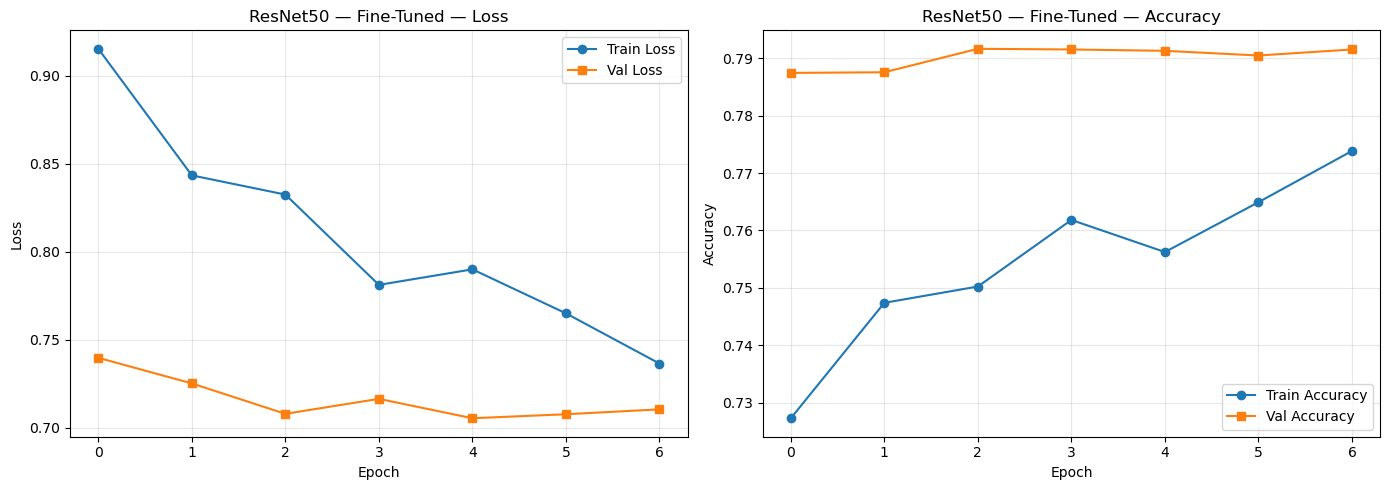

In [20]:
# Plot training history
plot_training_history(
    history_finetune.history,
    title="ResNet50 — Fine-Tuned",
    save_path=os.path.join(cfg["paths"]["evaluations"], "resnet50_finetuned_history.png"),
)

In [21]:
os.makedirs(cfg["paths"]["histories"], exist_ok=True )
with open(os.path.join(cfg["paths"]["histories"], "resnet50_finetuned.json"), "w") as f:
    json.dump(history_finetune.history, f, indent=2)

print("Training history saved.")

Training history saved.


### 6. Compare Frozen vs Fine-Tuned

In [23]:
# load frozen history
with open(os.path.join(cfg["paths"]["histories"], "resnet50_frozen.json"), "r") as f:
    history_frozen = json.load(f)

Saved plot to ../artefacts/evaluations\resnet50_comparison.png


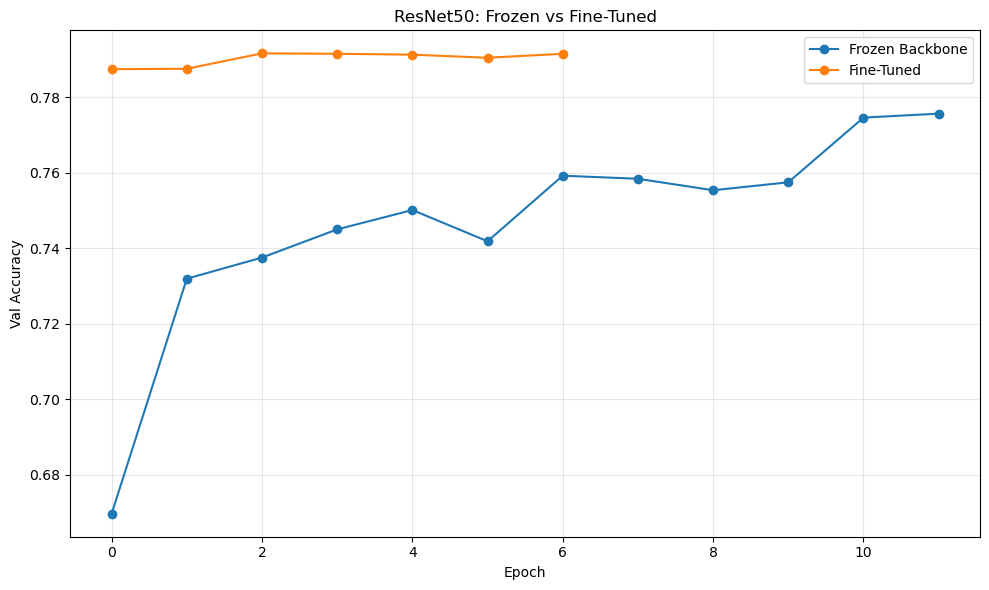

In [ ]:
from src.evaluation.viz import plot_multiple_histories, models_comparison

histories = {
    "Frozen Backbone": history_frozen.history,
    "Fine-Tuned": history_finetune.history,
}

plot_multiple_histories(
    histories,
    metric="val_accuracy",
    title="ResNet50: Frozen vs Fine-Tuned",
    save_path=os.path.join(cfg["paths"]["evaluations"], "resnet50_comparison.png"),
)

In [44]:
comparison = {
    "ResNet50 Frozen": results_frozen,
    "ResNet50 Fine-Tuned": results_finetune,
}

models_comparison(comparison)

Model                                accuracy             loss   top_5_accuracy
ResNet50 Frozen                        0.7756           0.8195           0.9669 
ResNet50 Fine-Tuned                    0.7916           0.7080           0.9702 


### 7. Evaluations

The fine-tuned model is evaluated and confusion matrix, per-class metrics and top confused pairs are visualized.

In [45]:
# predictions
from src.evaluation.metrics import get_predictions, compute_confusion_matrix

y_pred, y_true = get_predictions(model, val_prep)
print(f"Predictions shape: {y_pred.shape}")
print(f"True labels shape: {y_true.shape}")

Predictions shape: (8580,)
True labels shape: (8580,)


Saved plot to ../artefacts/evaluations\resnet50_confusion_matrix.png


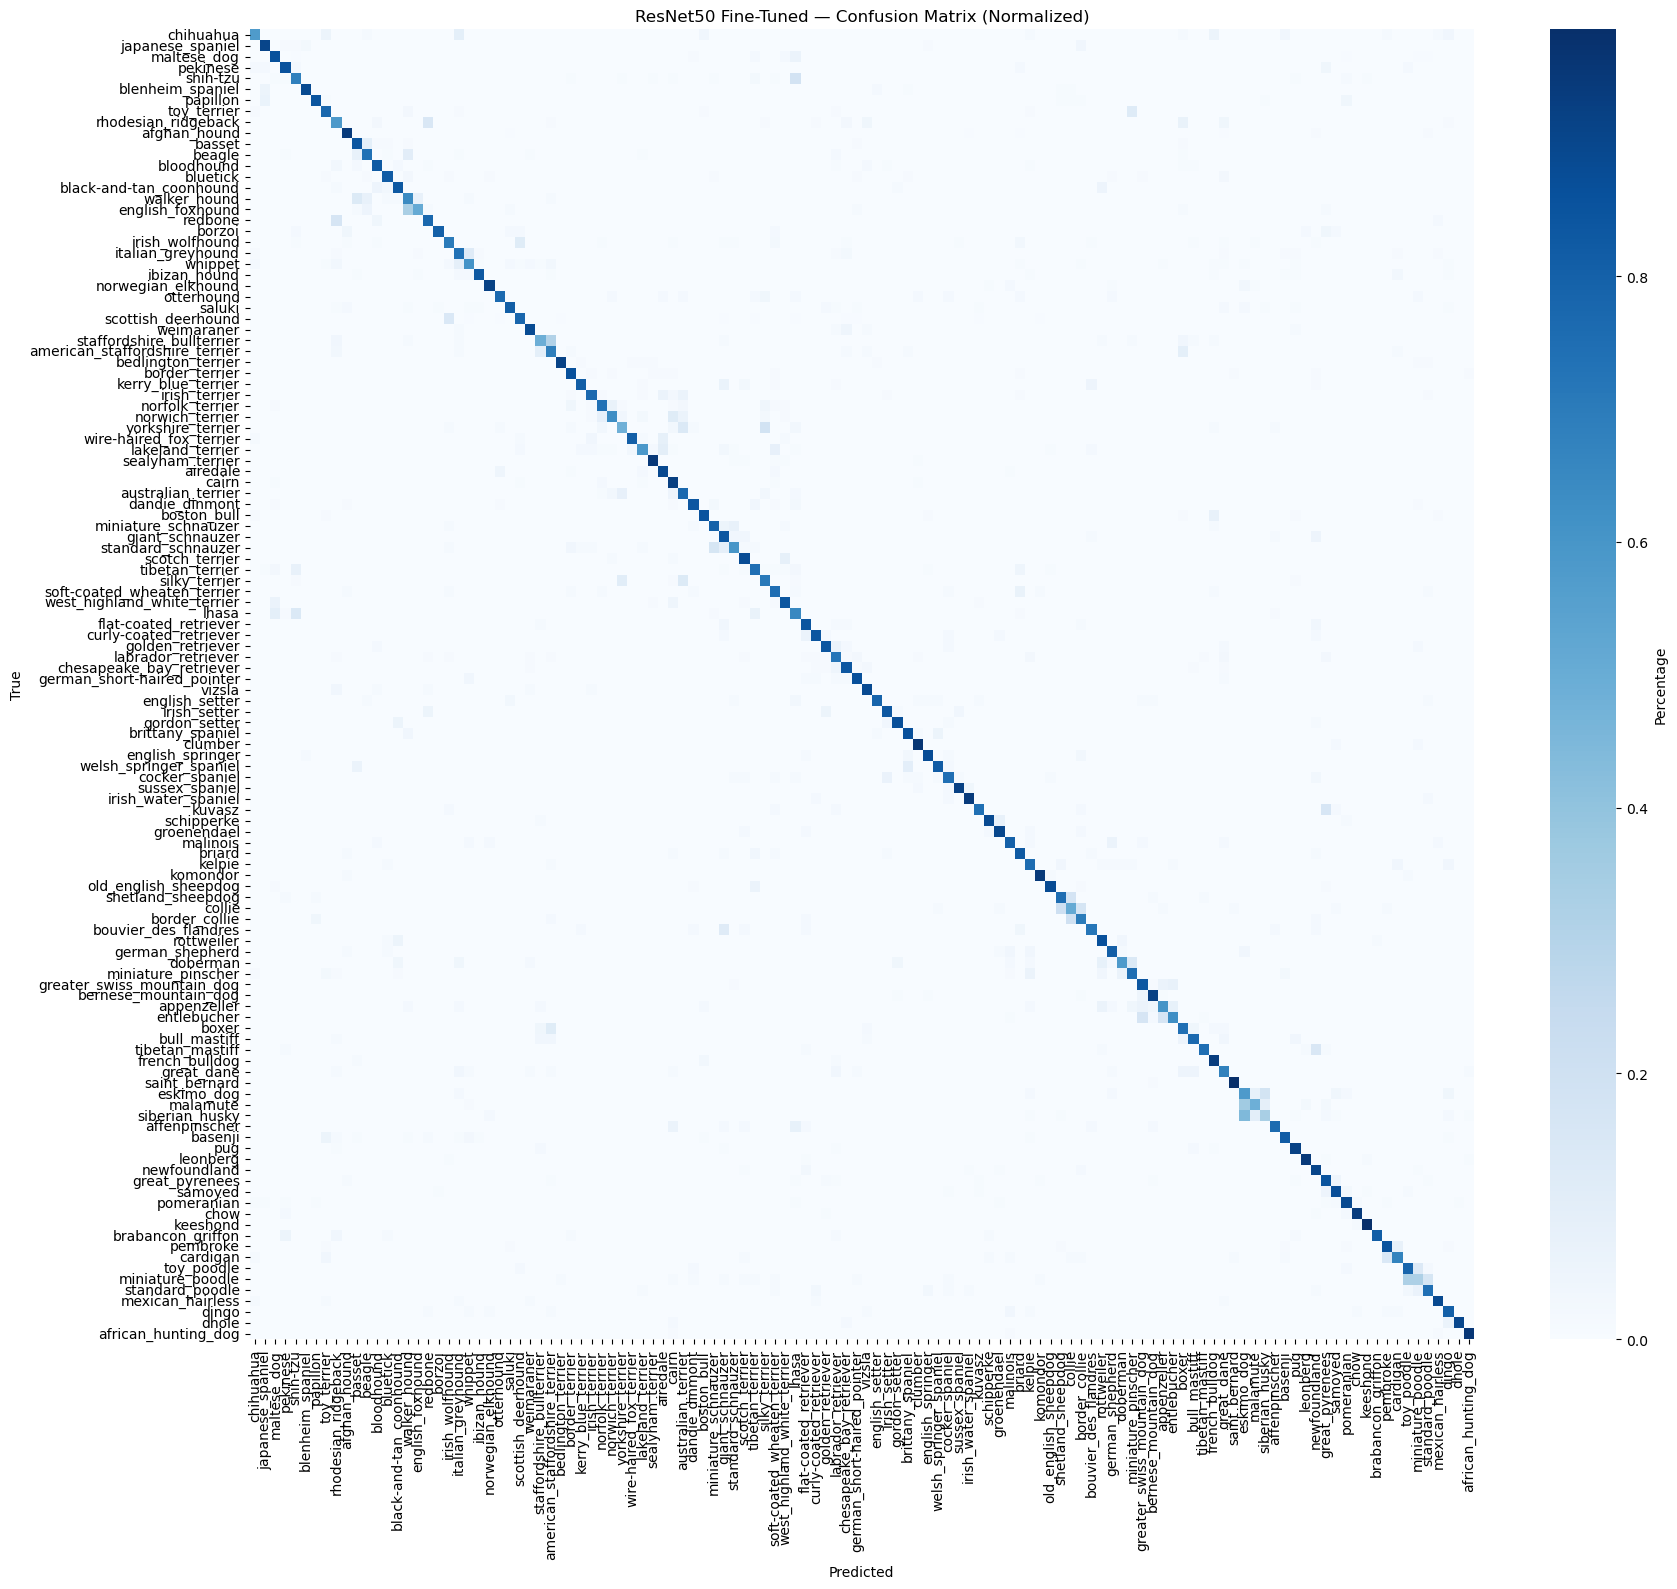

In [46]:
# confusion matrix

from src.evaluation.viz import plot_confusion_matrix

cm = compute_confusion_matrix(y_true, y_pred, num_classes)
plot_confusion_matrix(
    cm,
    class_names,
    normalize=True,
    title="ResNet50 Fine-Tuned — Confusion Matrix (Normalized)",
    figsize=(18, 16),
    save_path=os.path.join(cfg["paths"]["evaluations"], "resnet50_confusion_matrix.png"),
)


Top 10 Most Confused Pairs:
 1.                 siberian_husky → eskimo_dog                     :  41 errors
 2.                       malamute → eskimo_dog                     :  28 errors
 3.                       shih-tzu → lhasa                          :  21 errors
 4.               english_foxhound → walker_hound                   :  19 errors
 5.             scottish_deerhound → irish_wolfhound                :  19 errors
 6.               miniature_poodle → toy_poodle                     :  18 errors
 7.      staffordshire_bullterrier → american_staffordshire_terrier :  17 errors
 8.                    entlebucher → greater_swiss_mountain_dog     :  17 errors
 9.                    entlebucher → appenzeller                    :  17 errors
10.                irish_wolfhound → scottish_deerhound             :  14 errors
Saved plot to ../artefacts/evaluations\resnet50_confused_pairs.png


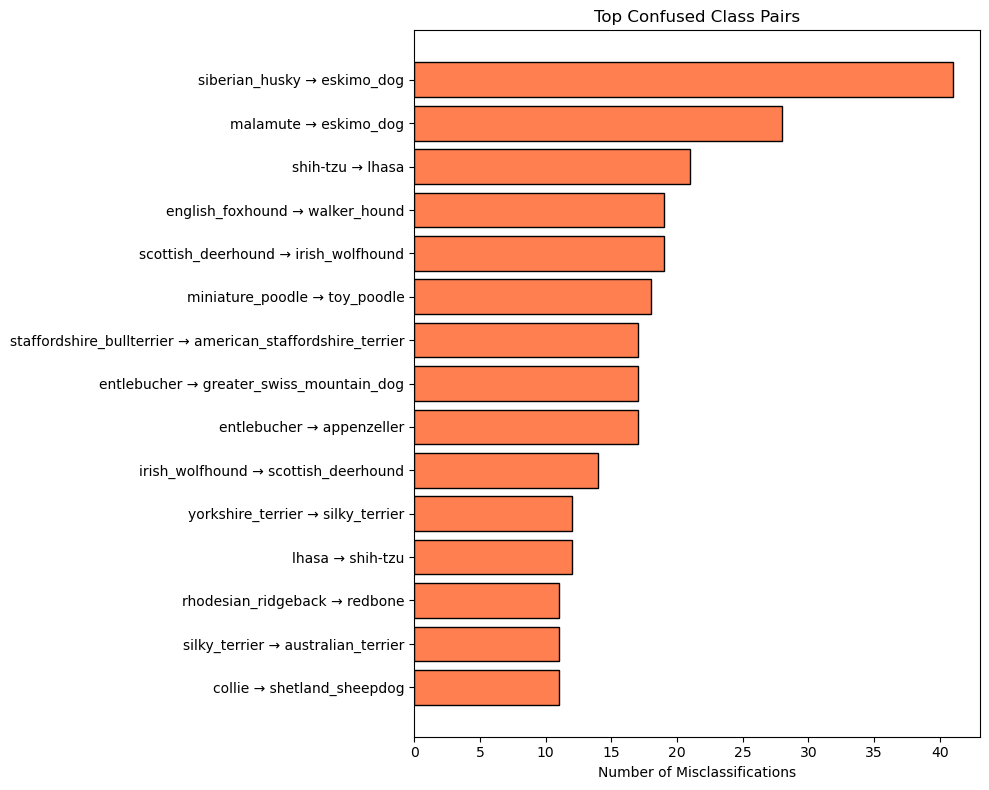

In [47]:
# plot confused pairs
from src.evaluation.metrics import top_confused_pairs
from src.evaluation.viz import plot_top_k_confusion_pairs

confused_pairs = top_confused_pairs(cm, class_names, top_k=15)
print("Top 10 Most Confused Pairs:")
for i, (true_cls, pred_cls, count) in enumerate(confused_pairs[:10], 1):
    print(f"{i:2d}. {true_cls:>30s} → {pred_cls:<30s} : {count:3d} errors")

plot_top_k_confusion_pairs(
    confused_pairs,
    top_k=15,
    save_path=os.path.join(cfg["paths"]["evaluations"], "resnet50_confused_pairs.png"),
)

10 Worst Performing Classes (by F1):
                    eskimo_dog  F1=0.372  Precision=0.274  Recall=0.580
              miniature_poodle  F1=0.396  Precision=0.500  Recall=0.327
                siberian_husky  F1=0.440  Precision=0.633  Recall=0.337
                        collie  F1=0.524  Precision=0.540  Recall=0.509
             yorkshire_terrier  F1=0.530  Precision=0.585  Recall=0.484
                  walker_hound  F1=0.535  Precision=0.459  Recall=0.642
     staffordshire_bullterrier  F1=0.551  Precision=0.628  Recall=0.491
                         lhasa  F1=0.574  Precision=0.514  Recall=0.651
           rhodesian_ridgeback  F1=0.575  Precision=0.568  Recall=0.583
                      malamute  F1=0.580  Precision=0.717  Recall=0.487
Saved plot to ../artefacts/evaluations\resnet50_worst_classes.png


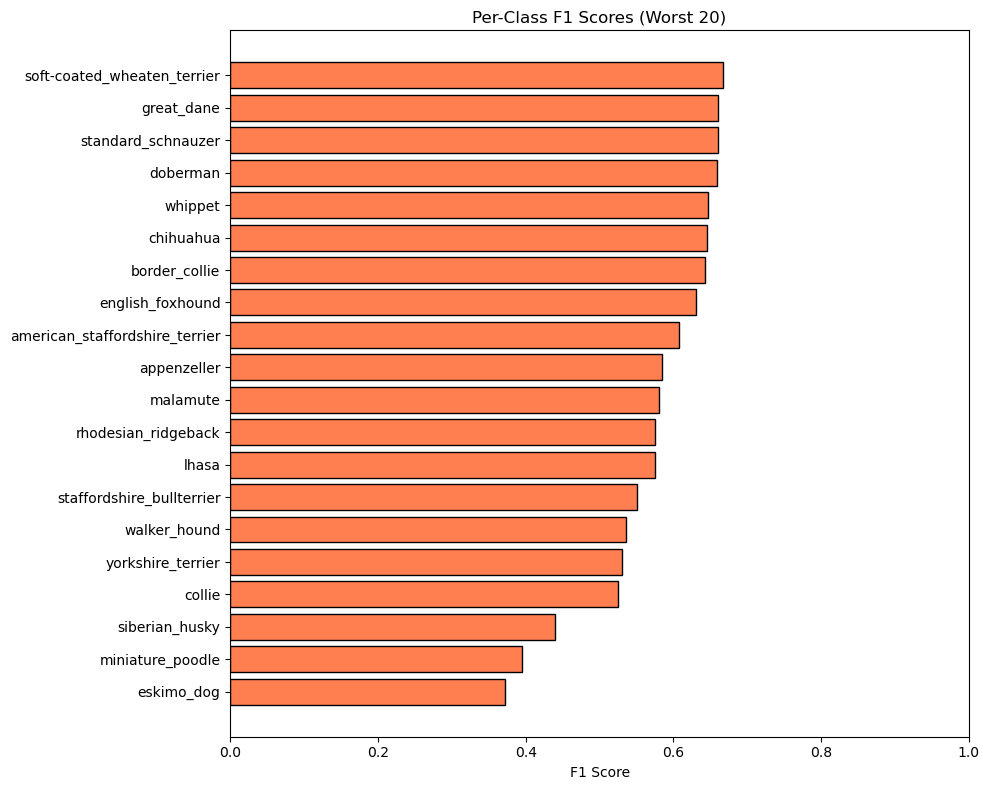

In [48]:
from src.evaluation.metrics import get_per_class_metrics
from src.evaluation.viz import plot_per_class_f1

per_class_metrics = get_per_class_metrics(y_true, y_pred, class_names)

print("10 Worst Performing Classes (by F1):")
worst_10 = list(per_class_metrics.items())[:10]
for name, scores in worst_10:
    print(f"{name:>30s}  F1={scores['f1']:.3f}  Precision={scores['precision']:.3f}  Recall={scores['recall']:.3f}")

# Plot worst 20
plot_per_class_f1(
    per_class_metrics,
    top_n=20,
    worst=True,
    save_path=os.path.join(cfg["paths"]["evaluations"], "resnet50_worst_classes.png"),
)

In [49]:
from tensorflow.keras.utils import plot_model

os.makedirs(cfg["paths"]["architecture_diagrams"], exist_ok=True)

plot_model(
    model,
    to_file=os.path.join(cfg["paths"]["architecture_diagrams"], "resnet50_architecture.png"),
    show_shapes=True,
    show_layer_names=True,
    rankdir="TB",  # Top to bottom
    expand_nested=False,
    dpi=150,
)

print("Saved model architecture diagram")

Saved model architecture diagram


### 8. Summary



**Frozen Backbone Results:**
- Val Accuracy: 77.56%
- Val Top-5 Accuracy: 96.69%
- Val Loss: 0.8195
- Trainable Parameters ≈ 245,880 (classifier head only)

**Fine-Tuned Results:**
- Val Accuracy: 79.16%
- Val Top-5 Accuracy: 97.02%
- Val Loss: 0.70798
- Trainable Parameters: 4,705,400
- Improvement over Frozen: 2.06%

**Key Observations:**
- Top confused pairs are likely within breed families (spaniels, retrievers, terriers)
- Classes with low F1 scores may have fewer test samples 
- Fine-tuning provides modest gains but at higher computational cost